# Environment Setup


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import yfinance as yf


# Data Collection (EGX Stocks)


In [ ]:
egx_tickers = [
    "COMI.CA", "SWDY.CA", "ETEL.CA", "TMGH.CA", "EGAL.CA", "MFPC.CA",
    "QNBE.CA", "ABUK.CA", "HDBK.CA", "EAST.CA", "ALCN.CA", "ORAS.CA",
    "EFIH.CA", "EMFD.CA", "ADIB.CA", "FWRY.CA", "SCTS.CA", "ORHD.CA",
    "EFID.CA", "CANA.CA", "OCDI.CA", "GPPL.CA", "VLMR.CA", "VLMRA.CA",
    "PHDC.CA", "JUFO.CA", "HRHO.CA", "GBCO.CA", "HELI.CA", "CIEB.CA"
]

import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

start_date = "2015-01-01"

all_stocks_data = []
failed_tickers = []

for ticker in egx_tickers:
    try:
        df_stock = yf.download(ticker, start=start_date, progress=False, auto_adjust=True)

        if not df_stock.empty:
            if isinstance(df_stock.columns, pd.MultiIndex):
                df_stock.columns = df_stock.columns.droplevel(1)

            df_stock['Ticker'] = ticker
            all_stocks_data.append(df_stock)
        else:
            failed_tickers.append(ticker)
    except Exception as e:
        failed_tickers.append(ticker)

df_final = pd.concat(all_stocks_data)
df_final.reset_index(inplace=True)


try:
    usd_egp = yf.download("EGP=X", start=start_date, progress=False, auto_adjust=True)
    if isinstance(usd_egp.columns, pd.MultiIndex):
        usd_egp.columns = usd_egp.columns.droplevel(1)

    usd_egp = usd_egp[['Close']].rename(columns={'Close': 'USD_EGP'})

    df_final = pd.merge(df_final, usd_egp, left_on='Date', right_index=True, how='left')

    df_final['USD_EGP'] = df_final['USD_EGP'].ffill()
    print("USD/EGP data merged successfully!")
except Exception as e:
    print(f"Failed to get USD/EGP data: {e}")


df_final = df_final.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

print("-" * 50)
print(f"Dataset is ready! Total rows: {df_final.shape[0]}, Total columns: {df_final.shape[1]}")
print(f"Tickers downloaded successfully: {df_final['Ticker'].nunique()} / {len(egx_tickers)}")
print(f"Tickers with no data on Yahoo Finance ({len(failed_tickers)}): {failed_tickers}")
print(f"Date Range: {df_final['Date'].min().date()} to {df_final['Date'].max().date()}")


USD/EGP data merged successfully!
--------------------------------------------------
Dataset is ready! Total rows: 72927, Total columns: 8
Tickers downloaded successfully: 27 / 30
Tickers with no data on Yahoo Finance (3): ['QNBE.CA', 'VLMR.CA', 'VLMRA.CA']
Date Range: 2015-01-04 to 2026-09-15


In [ ]:

def create_features(df):
    df['return_1d'] = df['Close'].pct_change(1)
    df['return_5d'] = df['Close'].pct_change(5)
    df['return_20d'] = df['Close'].pct_change(20)

    df['usd_return_1d'] = df['USD_EGP'].pct_change(1)
    df['usd_return_5d'] = df['USD_EGP'].pct_change(5)
    df['usd_return_20d'] = df['USD_EGP'].pct_change(20)

    sma_20 = df['Close'].rolling(window=20).mean()
    sma_50 = df['Close'].rolling(window=50).mean()
    sma_100 = df['Close'].rolling(window=100).mean()

    df['dist_sma_20'] = (df['Close'] / sma_20) - 1
    df['dist_sma_50'] = (df['Close'] / sma_50) - 1
    df['dist_sma_100'] = (df['Close'] / sma_100) - 1

    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))

    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    df['macd_pct'] = macd / df['Close']
    df['macd_signal_pct'] = df['macd_pct'].ewm(span=9, adjust=False).mean()

    rolling_std = df['Close'].rolling(window=20).std()
    bollinger_high = sma_20 + (rolling_std * 2)
    bollinger_low = sma_20 - (rolling_std * 2)
    df['bollinger_pb'] = (df['Close'] - bollinger_low) / (bollinger_high - bollinger_low + 1e-8)

    df['volatility_20d'] = df['return_1d'].rolling(window=20).std()
    vol_sma_20 = df['Volume'].rolling(window=20).mean()
    df['vol_ratio'] = df['Volume'] / (vol_sma_20 + 1e-8)

    forecast_horizon = 60
    df['target_direction'] = (df['Close'].shift(-forecast_horizon) > df['Close']).astype(int)
    df.loc[df.index[-forecast_horizon:], 'target_direction'] = np.nan

    return df

print("Applying features...")
df_features = df_final.groupby('Ticker', group_keys=False).apply(create_features)
df_features = df_features.dropna().reset_index(drop=True)
df_features['target_direction'] = df_features['target_direction'].astype(int)

df = df_features.sort_values("Date").reset_index(drop=True)

ticker_dummies = pd.get_dummies(df["Ticker"], prefix="ticker")
X = pd.concat([df.drop(columns=["target_direction", "Date", "Ticker", "Close", "High", "Low", "Open", "Volume", "USD_EGP"]), ticker_dummies], axis=1)
y = df["target_direction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
tscv = TimeSeriesSplit(n_splits=5)

print("Data is ready! Train shape:", X_train.shape, "Test shape:", X_test.shape)

Applying features...


/tmp/ipykernel_12115/592862561.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = df_final.groupby('Ticker', group_keys=False).apply(create_features)


Data is ready! Train shape: (54907, 42) Test shape: (13727, 42)


# Exploratory Data Analysis (EDA)

In [ ]:
df.head()

Price,Date,Close,High,Low,Open,Volume,Ticker,USD_EGP,return_1d,return_5d,...,dist_sma_20,dist_sma_50,dist_sma_100,rsi_14,macd_pct,macd_signal_pct,bollinger_pb,volatility_20d,vol_ratio,target_direction
0,2015-05-27,4.306334,4.306603,4.266622,4.293186,15450,ABUK.CA,7.6089,0.003062,0.005010,...,0.002693,0.007360,0.008445,55.063821,0.001411,0.001607,0.798833,0.002581,1.162331,0
1,2015-05-27,8.900373,9.006329,8.750267,8.935691,2571019,TMGH.CA,7.6089,-0.003952,0.015106,...,0.017257,0.009740,-0.031269,52.795818,0.002812,-0.003607,0.618200,0.030430,1.044592,0
2,2015-05-27,3.090937,3.107035,3.090937,3.092869,282470,SWDY.CA,7.6089,-0.000624,-0.000624,...,0.006068,0.009489,-0.003086,53.116298,0.004465,0.002836,0.601135,0.016129,0.149166,0
3,2015-05-27,6.794354,6.794354,6.794354,6.794354,0,SCTS.CA,7.6089,0.000000,0.000000,...,0.007151,0.014543,0.013383,75.402339,0.006004,0.005719,0.640683,0.006536,0.000000,0
4,2015-05-27,2.409113,2.463337,2.370381,2.447845,12491574,PHDC.CA,7.6089,-0.015823,0.118705,...,0.102446,0.031513,-0.048836,60.999091,0.009943,-0.014815,0.882478,0.035390,1.097777,0


In [ ]:
df.isnull().sum()

,0
Price,
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0
USD_EGP,0
return_1d,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71577 entries, 0 to 71576
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              71577 non-null  datetime64[ns]
 1   Close             71577 non-null  float64       
 2   High              71577 non-null  float64       
 3   Low               71577 non-null  float64       
 4   Open              71577 non-null  float64       
 5   Volume            71577 non-null  int64         
 6   Ticker            71577 non-null  object        
 7   USD_EGP           71577 non-null  float64       
 8   return_1d         71577 non-null  float64       
 9   return_5d         71577 non-null  float64       
 10  lag_close_1       71577 non-null  float64       
 11  lag_close_2       71577 non-null  float64       
 12  lag_vol_1         71577 non-null  float64       
 13  sma_10            71577 non-null  float64       
 14  sma_20            7157

In [ ]:
df.describe()

Price,Date,Close,High,Low,Open,Volume,USD_EGP,return_1d,return_5d,lag_close_1,...,sma_20,sma_50,sma_ratio,rsi_14,macd,macd_signal,bollinger_high,bollinger_low,volatility_20d,target_direction
count,71577,71577.000000,71577.000000,71577.000000,71577.000000,7.157700e+04,71577.000000,71577.000000,71577.000000,71577.000000,...,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000,71577.000000
mean,2021-02-10 13:32:54.952847872,20.395268,20.745896,20.087348,20.363313,2.328974e+06,24.869119,0.001112,0.005861,20.367686,...,20.128885,19.731184,1.011973,51.798922,0.189450,0.187053,21.874421,18.383350,0.020881,0.390014
min,2015-03-16 00:00:00,0.702206,0.721236,0.686982,0.702206,0.000000e+00,7.520400,-0.876695,-0.879596,0.702206,...,0.743216,0.826663,0.210742,0.000000,-100.376523,-87.827048,0.796119,-175.055449,0.000000,0.000000
25%,2018-04-15 00:00:00,4.878399,4.953435,4.773196,4.872236,3.979900e+04,15.702000,-0.008889,-0.022699,4.872236,...,4.857500,4.837570,0.976814,41.564491,-0.076484,-0.071205,5.290875,4.367242,0.013627,0.000000
50%,2021-03-09 00:00:00,9.210865,9.360985,9.085535,9.207694,5.429060e+05,17.858000,0.000000,0.000000,9.207523,...,9.188926,9.125239,1.003159,51.616625,0.012324,0.012892,9.883937,8.501403,0.019168,0.000000
75%,2023-12-18 00:00:00,21.750732,22.120001,21.379999,21.700952,2.248897e+06,30.888000,0.008792,0.028913,21.700953,...,21.502568,21.055911,1.044481,62.361223,0.203235,0.199950,23.350079,19.519131,0.026152,1.000000
max,2026-09-14 00:00:00,675.638428,810.766139,651.335610,675.638409,4.442114e+08,54.653801,0.455832,0.849045,675.638428,...,634.202353,615.484001,1.470206,100.000000,99.424043,85.210316,792.621491,613.293820,0.203876,1.000000
std,NaN,38.943466,39.864090,38.254188,38.824998,5.811693e+06,14.506203,0.024887,0.061095,38.852411,...,37.814421,36.059064,0.069466,18.627927,2.610050,2.465577,42.777739,34.101113,0.013253,0.487756


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
print(df["Date"].min())
print(df["Date"].max())

2015-03-16 00:00:00
2026-09-14 00:00:00


In [ ]:
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
df[["Date", "Close", "target_direction"]].head()

Price,Date,Close,target_direction
0,2015-03-16,4.271721,0
1,2015-03-16,14.859617,1
2,2015-03-16,4.330583,1
3,2015-03-16,2.203871,0
4,2015-03-16,2.719817,1


In [ ]:
# --- BUG ---
# This cell used to filter `df` down to a single stock:
#     Ticker = "CCAP.CA"
#     df = df[df["Ticker"] == Ticker].reset_index(drop=True)
# The assignment line got commented out at some point, so `Ticker` was
# never defined -> NameError.
#
# More importantly: even if we fix the NameError, this cell filters the
# whole dataset down to ONE stock. Since the goal now is to train on ALL
# stocks together, this cell should NOT run at all - keeping it would
# silently throw away every stock except CCAP.CA before the model ever
# sees the data. It's disabled on purpose; leave it disabled.


In [ ]:
#df["Ticker"].nunique()

In [ ]:
#df["Ticker"].value_counts()

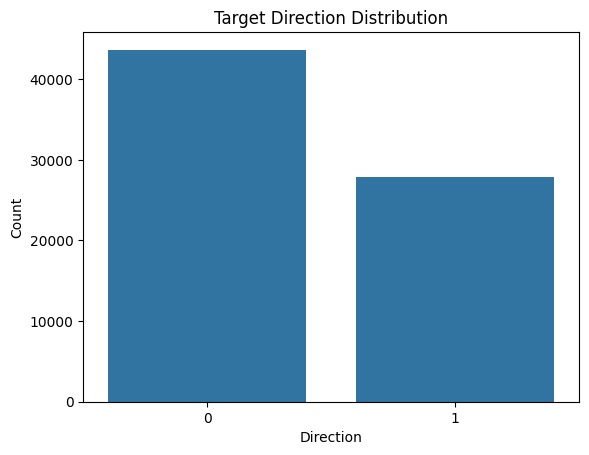

In [ ]:
sns.countplot(data=df, x="target_direction")
plt.title("Target Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.show()

In [ ]:
df["target_direction"].value_counts(normalize=True) * 100

,proportion
target_direction,
0,60.998645
1,39.001355


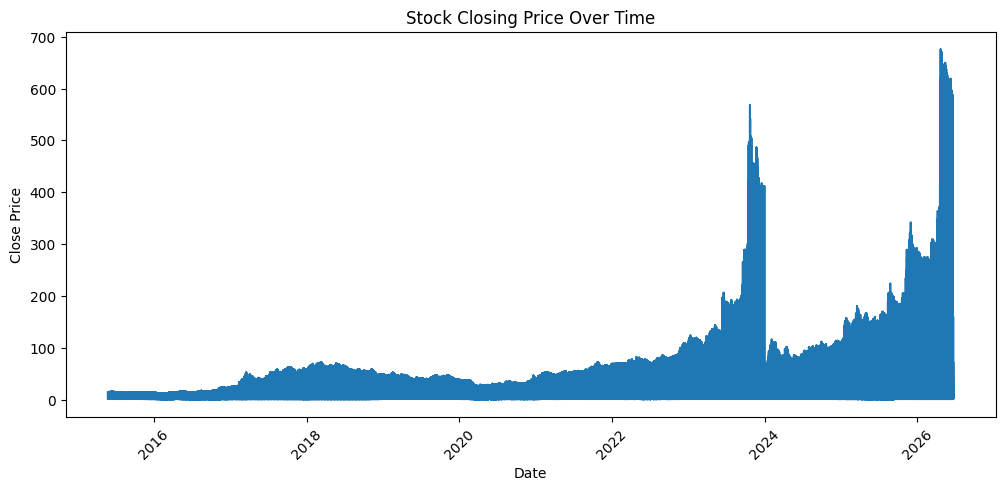

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"])

plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.show()

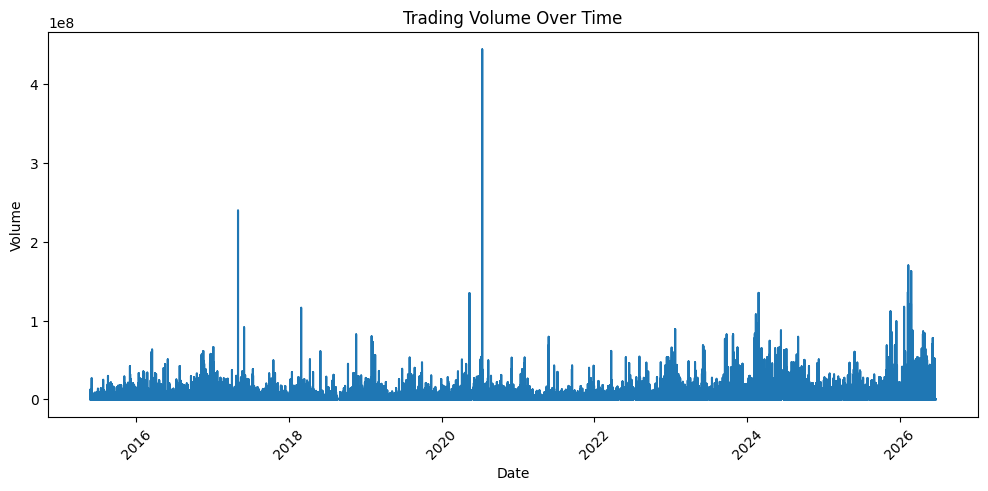

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.xticks(rotation=45)
plt.show()

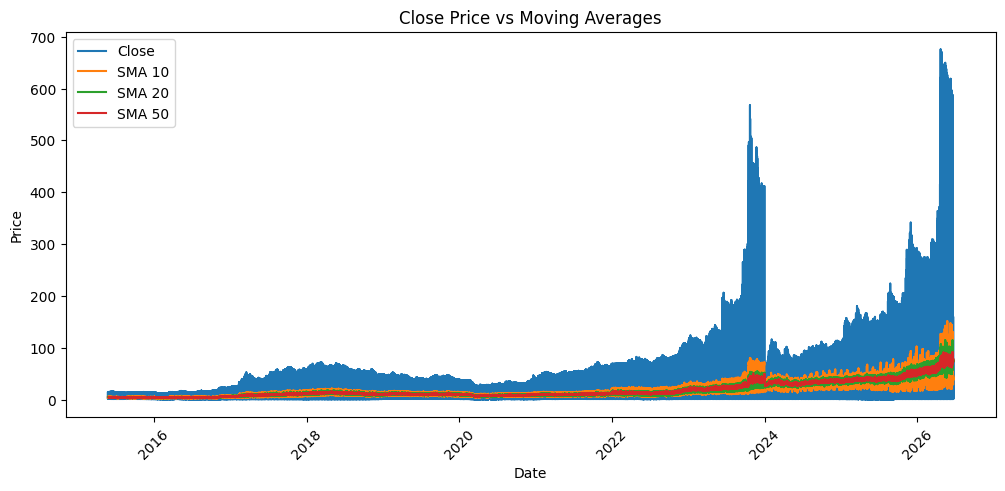

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["sma_10"], label="SMA 10")
plt.plot(df["Date"], df["sma_20"], label="SMA 20")
plt.plot(df["Date"], df["sma_50"], label="SMA 50")

plt.title("Close Price vs Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.xticks(rotation=45)
plt.show()

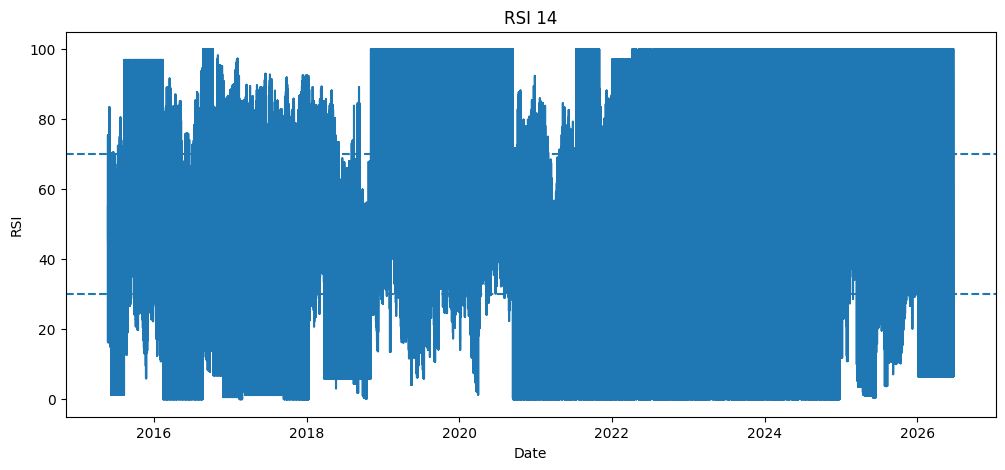

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["rsi_14"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("RSI 14")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.show()

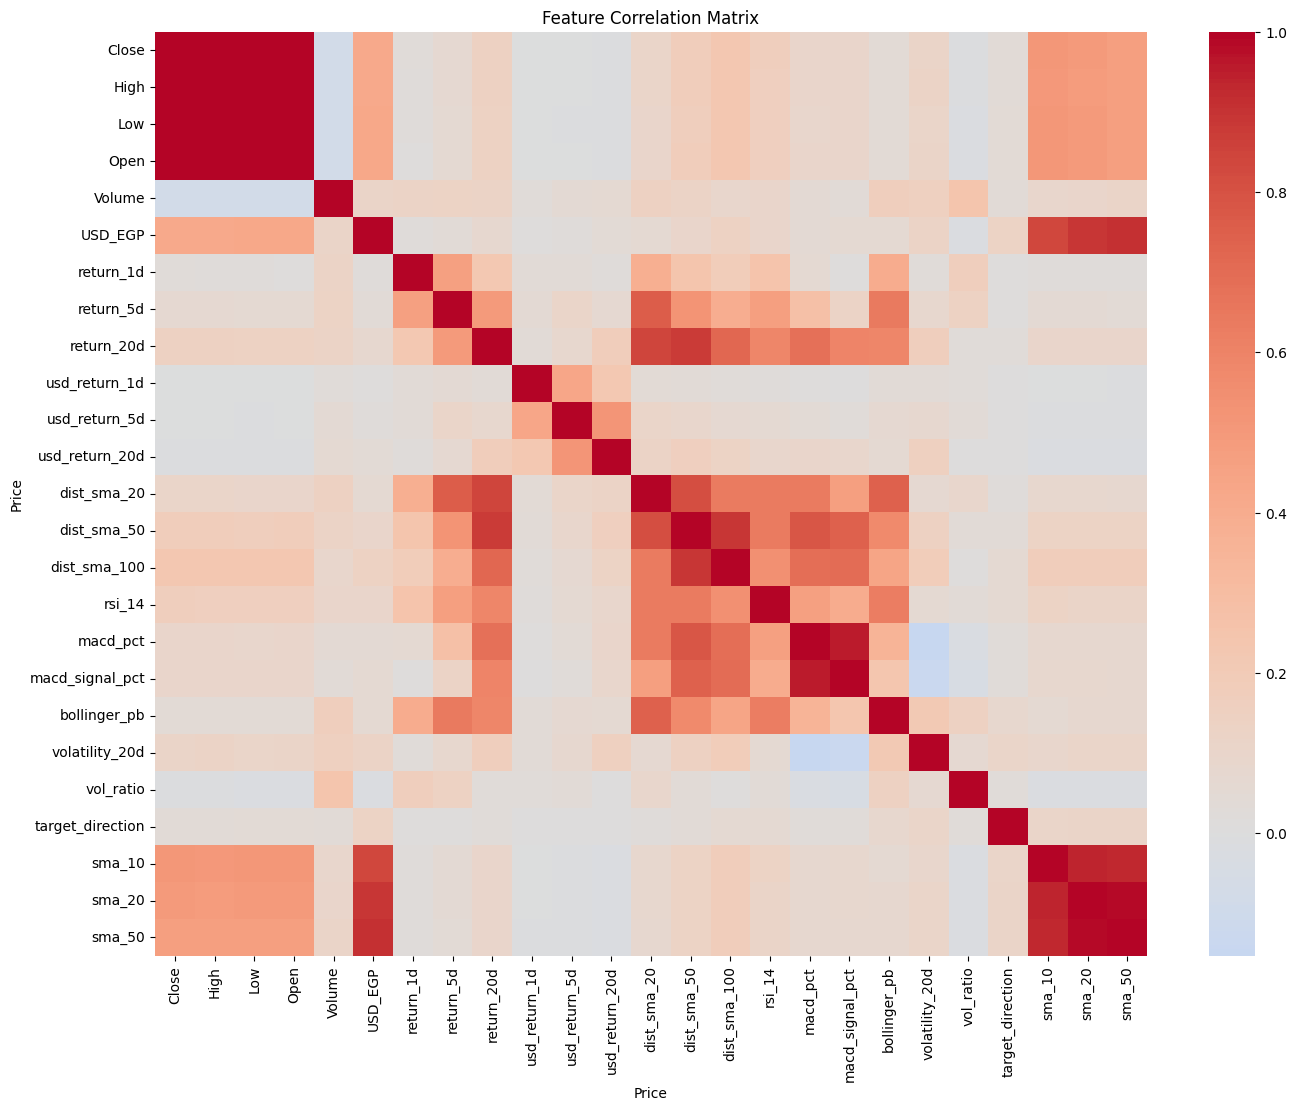

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

# Data Preprocessing

In [ ]:
X = df_features.drop(columns=["target_direction", "Date", "Ticker"])
y = df_features["target_direction"]

In [ ]:
X = df.drop(columns=["target_direction","Date","Ticker"])

In [ ]:
df = df.ffill()
df = df.dropna().reset_index(drop=True)

print(f"Missing values after handling: {df.isnull().sum().sum()}")

Missing values after handling: 0


In [ ]:
df = df.sort_values("Date").reset_index(drop=True)

ticker_dummies = pd.get_dummies(df["Ticker"], prefix="ticker")

X = pd.concat(
    [df.drop(columns=["target_direction", "Date", "Ticker"]), ticker_dummies],
    axis=1,
)
y = df["target_direction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
tscv = TimeSeriesSplit(n_splits=5)

print("Train period:", df.loc[X_train.index, "Date"].min().date(), "->", df.loc[X_train.index, "Date"].max().date())
print("Test period: ", df.loc[X_test.index, "Date"].min().date(), "->", df.loc[X_test.index, "Date"].max().date())


Train period: 2015-05-27 -> 2024-05-15
Test period:  2024-05-15 -> 2026-06-22


In [ ]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (54907, 48)
Test: (13727, 48)


#Modling

## Logistic Model

In [ ]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight='balanced' , max_iter=1000))
])


In [ ]:
log_cv_scores = cross_val_score(logistic_model, X_train, y_train, cv=tscv, scoring='accuracy')
print(f"Scores for the 5 splits: {log_cv_scores}")
print(f"Average Accuracy: {log_cv_scores.mean():.4f}\n")

Scores for the 5 splits: [0.57676757 0.54824609 0.56649546 0.58671183 0.62080647]
Average Accuracy: 0.5798



In [ ]:
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.6305092154148758
              precision    recall  f1-score   support

           0       0.38      0.16      0.22      4594
           1       0.67      0.87      0.76      9133

    accuracy                           0.63     13727
   macro avg       0.52      0.51      0.49     13727
weighted avg       0.57      0.63      0.58     13727



## Knn Model

In [ ]:
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
knn_cv_scores = cross_val_score(nn_model, X_train, y_train, cv=tscv, scoring='accuracy')
print(f"Scores for the 5 splits: {knn_cv_scores}")
print(f"Average Accuracy: {knn_cv_scores.mean():.4f}")

Scores for the 5 splits: [0.57425418 0.48180527 0.55075948 0.51611846 0.61414053]
Average Accuracy: 0.5474


In [ ]:
nn_model.fit(X_train, y_train)
y_pred_knn = nn_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

Accuracy: 0.5814089021636192
              precision    recall  f1-score   support

           0       0.40      0.49      0.44      4594
           1       0.71      0.63      0.67      9133

    accuracy                           0.58     13727
   macro avg       0.55      0.56      0.55     13727
weighted avg       0.61      0.58      0.59     13727



##Svm Model

In [ ]:
"""
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel='rbf', class_weight='balanced',  random_state=42))
])

svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=tscv, scoring='accuracy')

print(f"Scores for the 5 splits: {svm_cv_scores}")
print(f"Average Accuracy: {svm_cv_scores.mean():.4f}\n")
"""

'\nsvm_model = Pipeline([\n    ("scaler", StandardScaler()),\n    ("model", SVC(kernel=\'rbf\', class_weight=\'balanced\',  random_state=42))\n])\n\nsvm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=tscv, scoring=\'accuracy\')\n\nprint(f"Scores for the 5 splits: {svm_cv_scores}")\nprint(f"Average Accuracy: {svm_cv_scores.mean():.4f}\n")\n'

In [ ]:
"""
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)
"""

## Random Forest

In [ ]:
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced'))
])

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='accuracy')
print(f"Scores for the 5 splits: {rf_cv_scores}")
print(f"RF Average CV Accuracy: {rf_cv_scores.mean():.4f}\n")

Scores for the 5 splits: [0.58878811 0.41798711 0.57458201 0.54398426 0.69817506]
RF Average CV Accuracy: 0.5647



In [ ]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("-" * 40)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

----------------------------------------
Random Forest Accuracy: 0.6527281998980112
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.29      0.36      4594
           1       0.70      0.84      0.76      9133

    accuracy                           0.65     13727
   macro avg       0.58      0.56      0.56     13727
weighted avg       0.62      0.65      0.63     13727



In [ ]:
gb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))
])

gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=tscv, scoring='accuracy')
print(f"Scores for the 5 splits: {gb_cv_scores}")
print(f"GB Average CV Accuracy: {gb_cv_scores.mean():.4f}")

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_model.fit(X_train, y_train, model__sample_weight=sample_weights)
y_pred_gb = gb_model.predict(X_test)

print("-" * 40)
print("GB Accuracy:", accuracy_score(y_test, y_pred_gb))
print("GB Classification Report:")
print(classification_report(y_test, y_pred_gb))

Scores for the 5 splits: [0.61359414 0.39438313 0.53371216 0.55447492 0.68888646]
GB Average CV Accuracy: 0.5570
----------------------------------------
GB Accuracy: 0.6412908865739054
GB Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.38      0.42      4594
           1       0.71      0.77      0.74      9133

    accuracy                           0.64     13727
   macro avg       0.59      0.58      0.58     13727
weighted avg       0.63      0.64      0.63     13727



#Final Model

In [ ]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

xgb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

print("Evaluating XGBoost without forced weights...")
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=tscv, scoring='accuracy')

print(f"Scores for the 5 splits: {xgb_cv_scores}")
print(f"XGB Average CV Accuracy: {xgb_cv_scores.mean():.4f}\n")

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("-" * 40)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

Evaluating XGBoost without forced weights...
Scores for the 5 splits: [0.59523549 0.40509234 0.5599388  0.54988526 0.68560813]
XGB Average CV Accuracy: 0.5592

----------------------------------------
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.53      0.45      4594
           1       0.71      0.59      0.64      9133

    accuracy                           0.57     13727
   macro avg       0.55      0.56      0.55     13727
weighted avg       0.61      0.57      0.58     13727

XGBoost Accuracy: 0.5672033219203031


# Evaluation

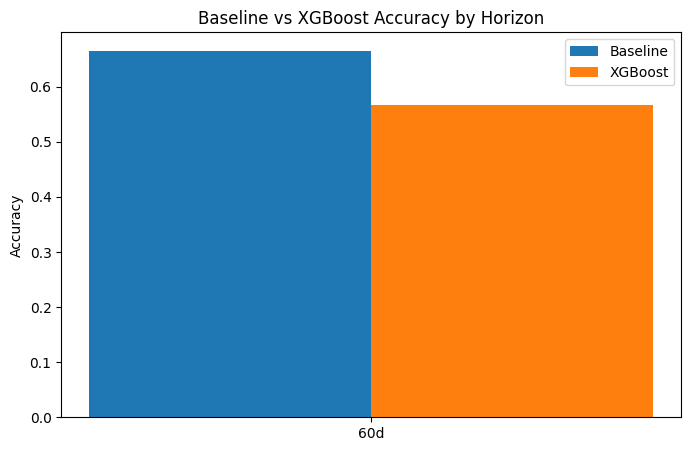

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["baseline_acc"], width, label="Baseline")
ax.bar(x + width/2, results_df["xgb_test_acc"], width, label="XGBoost")
ax.set_xticks(x)
ax.set_xticklabels(results_df["horizon"].astype(str) + "d")
ax.set_ylabel("Accuracy")
ax.set_title("Baseline vs XGBoost Accuracy by Horizon")
ax.legend()
plt.show()

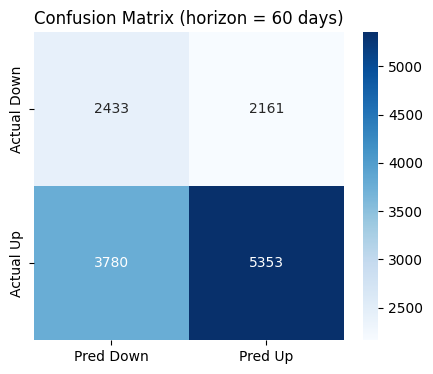

In [ ]:
cm = confusion_matrix(y_test_final, final_model.predict(X_test_final))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Down", "Pred Up"],
            yticklabels=["Actual Down", "Actual Up"])
plt.title(f"Confusion Matrix (horizon = {FINAL_HORIZON} days)")
plt.show()

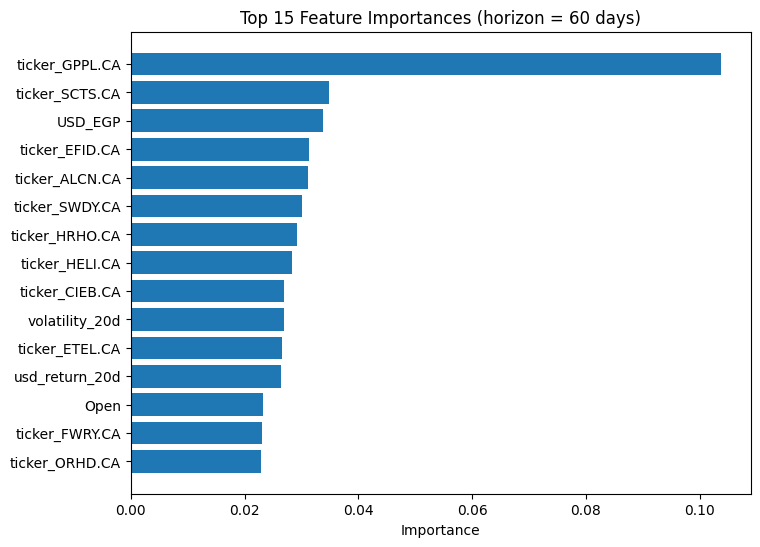

In [ ]:
importances = final_model.named_steps["model"].feature_importances_;
feat_names = X_test_final.columns
top_n = 15
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), feat_names[top_idx])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (horizon = {FINAL_HORIZON} days)")
plt.show()